<a href="https://colab.research.google.com/github/vennela-236/project-1/blob/main/Rice_and_Wheat_leaf_Disease_Classification_and_Detection_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = 'vennelasreevadam'  # your Kaggle username
os.environ['KAGGLE_KEY'] = 'KGAT_3b6a5c5f5af29be1fb5010529cabbb47'  # paste your token here

!pip install kaggle -q

!kaggle datasets download vbookshelf/rice-leaf-diseases
!kaggle datasets download olyadgetch/wheat-leaf-dataset

Dataset URL: https://www.kaggle.com/datasets/vbookshelf/rice-leaf-diseases
License(s): unknown
100% 36.7M/36.7M [00:01<00:00, 22.0MB/s]

Dataset URL: https://www.kaggle.com/datasets/olyadgetch/wheat-leaf-dataset
License(s): copyright-authors
100% 1.41G/1.41G [00:38<00:00, 39.0MB/s]



In [ ]:
from zipfile import ZipFile
dataset = '/content/rice-leaf-diseases.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print('The Dataset is successfully Extracted')


The Dataset is successfully Extracted


In [ ]:
from zipfile import ZipFile
dataset = '/content/wheat-leaf-dataset.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print('The Dataset is successfully Extracted')


The Dataset is successfully Extracted


In [ ]:
!ls

rice_leaf_diseases	sample_data  wheat-leaf-dataset.zip
rice-leaf-diseases.zip	wheat_leaf


In [ ]:
# Cell 1: Proper augmentation using tf.keras pipeline

import tensorflow as tf
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from collections import Counter

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 60
SEED = 42
TARGET = 300            # augment all classes to 300

RICE_PATH = '/content/rice_leaf_diseases'
WHEAT_PATH = '/content/wheat_leaf'
RICE_CLASSES  = ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']
WHEAT_CLASSES = ['Healthy', 'septoria', 'stripe_rust']

In [ ]:
# Cell 2: Diverse augmentation — avoids near-duplicates

def augment_diverse(images, target_count, seed=42):
    """
    Creates truly diverse augmented images using random combos of transforms.
    Applies DIFFERENT random params each time to avoid duplicates.
    """
    np.random.seed(seed)
    result = list(images)  # start with originals
    n_orig = len(images)

    while len(result) < target_count:
        # Pick a random original
        img = images[np.random.randint(0, n_orig)].copy().astype(np.float32)

        # Random rotation
        angle = np.random.uniform(-45, 45)
        M = cv2.getRotationMatrix2D((IMG_SIZE[0]//2, IMG_SIZE[1]//2), angle, 1.0)
        img = cv2.warpAffine(img, M, IMG_SIZE)

        # Random flip
        if np.random.rand() > 0.5:
            img = cv2.flip(img, 1)
        if np.random.rand() > 0.5:
            img = cv2.flip(img, 0)

        # Random brightness & contrast
        alpha = np.random.uniform(0.6, 1.4)  # contrast
        beta  = np.random.uniform(-40, 40)   # brightness
        img = np.clip(alpha * img + beta, 0, 255)

        # Random zoom (crop then resize)
        zoom = np.random.uniform(0.75, 1.0)
        h, w = IMG_SIZE
        ch, cw = int(h * zoom), int(w * zoom)
        top  = np.random.randint(0, h - ch + 1)
        left = np.random.randint(0, w - cw + 1)
        img = img[top:top+ch, left:left+cw]
        img = cv2.resize(img, IMG_SIZE)

        # Random Gaussian noise
        if np.random.rand() > 0.5:
            noise = np.random.normal(0, np.random.uniform(2, 10), img.shape)
            img = np.clip(img + noise, 0, 255)

        # Random channel shuffle (simulates different lighting)
        if np.random.rand() > 0.7:
            ch_order = np.random.permutation(3)
            img = img[:, :, ch_order]

        result.append(img.astype(np.uint8))

    np.random.shuffle(result)
    return result[:target_count]

In [ ]:
# Cell 3: Load images at 224x224 and augment to TARGET

def load_and_augment(base_path, class_list, target=TARGET):
    X, y = [], []
    for idx, cls in enumerate(class_list):
        cls_path = os.path.join(base_path, cls)
        imgs = []
        for fname in os.listdir(cls_path):
            fpath = os.path.join(cls_path, fname)
            img = cv2.imread(fpath)
            if img is not None:
                img = cv2.resize(img, IMG_SIZE)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                imgs.append(img)

        print(f"  [{cls}] {len(imgs)} original → augmenting to {target}")
        imgs_aug = augment_diverse(imgs, target, seed=SEED + idx)

        for img in imgs_aug:
            X.append(img)
            y.append(idx)

    X = np.array(X, dtype=np.float32) / 255.0
    y = np.array(y)
    return X, y

print("augmenting Rice dataset")
X_rice_d, y_rice_d = load_and_augment(RICE_PATH, RICE_CLASSES, target=TARGET)

print("\naugmenting Wheat dataset")
X_wheat_d, y_wheat_d = load_and_augment(WHEAT_PATH, WHEAT_CLASSES, target=TARGET)

print(f"\nRice  shape: {X_rice_d.shape}")
print(f"Wheat shape: {X_wheat_d.shape}")

augmenting Rice dataset
  [Bacterial leaf blight] 40 original → augmenting to 300
  [Brown spot] 40 original → augmenting to 300
  [Leaf smut] 40 original → augmenting to 300

augmenting Wheat dataset
  [Healthy] 102 original → augmenting to 300
  [septoria] 97 original → augmenting to 300
  [stripe_rust] 208 original → augmenting to 300

Rice  shape: (900, 224, 224, 3)
Wheat shape: (900, 224, 224, 3)


In [ ]:
# Cell 4: Stage 1 binary dataset

X_s1 = np.concatenate([X_rice_d[:TARGET], X_wheat_d[:TARGET]], axis=0)
y_s1 = np.array([0]*TARGET + [1]*TARGET)

idx = np.random.RandomState(SEED).permutation(len(X_s1))
X_s1, y_s1 = X_s1[idx], y_s1[idx]

X_train_s1, X_test_s1, y_train_s1, y_test_s1 = train_test_split(
    X_s1, y_s1, test_size=0.2, random_state=SEED, stratify=y_s1
)

print(f"Stage 1 — Train: {X_train_s1.shape}, Test: {X_test_s1.shape}")
print(f"Train class balance: {Counter(y_train_s1)}")

Stage 1 — Train: (480, 224, 224, 3), Test: (120, 224, 224, 3)
Train class balance: Counter({np.int64(0): 240, np.int64(1): 240})


In [ ]:
# Cell 5: Stage 2 disease datasets

y_rice_cat  = to_categorical(y_rice_d,  num_classes=len(RICE_CLASSES))
y_wheat_cat = to_categorical(y_wheat_d, num_classes=len(WHEAT_CLASSES))

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_rice_d, y_rice_cat, test_size=0.2,
    random_state=SEED, stratify=y_rice_d
)

Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_wheat_d, y_wheat_cat, test_size=0.2,
    random_state=SEED, stratify=y_wheat_d
)

print(f"Rice Disease  — Train: {Xr_train.shape}, Test: {Xr_test.shape}")
print(f"Wheat Disease — Train: {Xw_train.shape}, Test: {Xw_test.shape}")

Rice Disease  — Train: (720, 224, 224, 3), Test: (180, 224, 224, 3)
Wheat Disease — Train: (720, 224, 224, 3), Test: (180, 224, 224, 3)


In [ ]:
# Cell 6: Transfer Learning model — MobileNetV2 backbone + 4 DCNN-style layers

def build_transfer_model(num_classes, name="Model"):
    # Pretrained backbone (frozen initially)
    backbone = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    backbone.trainable = False  # freeze first

    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = backbone(inputs, training=False)

    # 4 custom DCNN-style layers on top of backbone
    # Layer 1
    x = layers.Conv2D(256, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    # Layer 2
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    # Layer 3
    x = layers.Conv2D(64, (1,1), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)

    # Layer 4
    x = layers.Conv2D(32, (1,1), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # Classifier
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    if num_classes == 2:
        outputs = layers.Dense(1, activation='sigmoid')(x)
        loss = 'binary_crossentropy'
    else:
        outputs = layers.Dense(num_classes, activation='softmax')(x)
        loss = 'categorical_crossentropy'

    model = tf.keras.Model(inputs, outputs, name=name)
    return model, backbone, loss

print("Transfer model builder ready.")

Transfer model builder ready.


In [ ]:
# Cell 7: Two-phase training for all 3 models

def train_two_phase(model, backbone, loss_fn, X_train, y_train,
                    X_test, y_test, name, cw=None):

    callbacks = [
        EarlyStopping(patience=8, restore_best_weights=True, monitor='val_accuracy'),
        ReduceLROnPlateau(patience=4, factor=0.3, min_lr=1e-7, verbose=1)
    ]

    # Phase 1: Train only custom top layers (backbone frozen)
    print(f"[{name}] Phase 1: Training top layers (backbone frozen)")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=loss_fn, metrics=['accuracy']
    )
    h1 = model.fit(
        X_train, y_train,
        validation_split=0.15,
        epochs=20, batch_size=BATCH_SIZE,
        callbacks=callbacks, class_weight=cw, verbose=1
    )

    # Phase 2: Unfreeze last 30 layers of backbone (fine-tune)
    print(f"\n[{name}] Phase 2: Fine-tuning (unfreezing last 30 backbone layers)")
    backbone.trainable = True
    for layer in backbone.layers[:-30]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-5),  # very low LR for fine-tune
        loss=loss_fn, metrics=['accuracy']
    )
    h2 = model.fit(
        X_train, y_train,
        validation_split=0.15,
        epochs=40, batch_size=BATCH_SIZE,
        callbacks=callbacks, class_weight=cw, verbose=1
    )

    # Evaluate
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"\n[{name}] Final Test Accuracy: {acc*100:.2f}%")

    # Merge histories
    merged = {}
    for k in h1.history:
        merged[k] = h1.history[k] + h2.history[k]

    class FakeHistory:
        def __init__(self, d): self.history = d

    return FakeHistory(merged), acc


import builtins

def get_cw(y_labels):
    classes = np.unique(y_labels)
    w = compute_class_weight('balanced', classes=classes, y=y_labels)
    # Use builtins.zip to bypass the ZipFile conflict
    return dict(builtins.zip(classes.tolist(), w))


# Train Stage 1
m_s1, bb_s1, loss_s1_fn = build_transfer_model(2, name="Stage1_RiceVsWheat")
cw_s1 = get_cw(y_train_s1)
history_s1, acc_s1 = train_two_phase(
    m_s1, bb_s1, loss_s1_fn,
    X_train_s1, y_train_s1,
    X_test_s1, y_test_s1,
    name="Stage1", cw=cw_s1
)

# Train Stage 2a Rice
m_rice, bb_rice, loss_rice_fn = build_transfer_model(len(RICE_CLASSES), name="RiceDisease")
cw_rice = get_cw(np.argmax(yr_train, axis=1))
history_rice, acc_rice = train_two_phase(
    m_rice, bb_rice, loss_rice_fn,
    Xr_train, yr_train,
    Xr_test, yr_test,
    name="RiceDisease", cw=cw_rice
)

# Train Stage 2b Wheat
m_wheat, bb_wheat, loss_wheat_fn = build_transfer_model(len(WHEAT_CLASSES), name="WheatDisease")
cw_wheat = get_cw(np.argmax(yw_train, axis=1))
history_wheat, acc_wheat = train_two_phase(
    m_wheat, bb_wheat, loss_wheat_fn,
    Xw_train, yw_train,
    Xw_test, yw_test,
    name="WheatDisease", cw=cw_wheat
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
[Stage1] Phase 1: Training top layers (backbone frozen)
Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.9534 - loss: 0.2419 - val_accuracy: 0.9722 - val_loss: 0.0744 - learning_rate: 0.0010
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9975 - loss: 0.0307 - val_accuracy: 0.9861 - val_loss: 0.0250 - learning_rate: 0.0010
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9828 - loss: 0.0380 - val_accuracy: 1.0000 - val_loss: 5.7130e-04 - learning_rate: 0.0010
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9902 - loss: 0.0344 - val_accuracy: 1.0000 - val_loss: 0.0030 - learning_rate: 0.0010
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9926 - loss: 0.0254 - val_accuracy: 1.0000 - val_loss: 5.2991e-05 - learning_rate: 0.0010
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9877 - loss: 0.0432 - val_accuracy: 1.0000 - val_loss: 2.9431e-04 - 

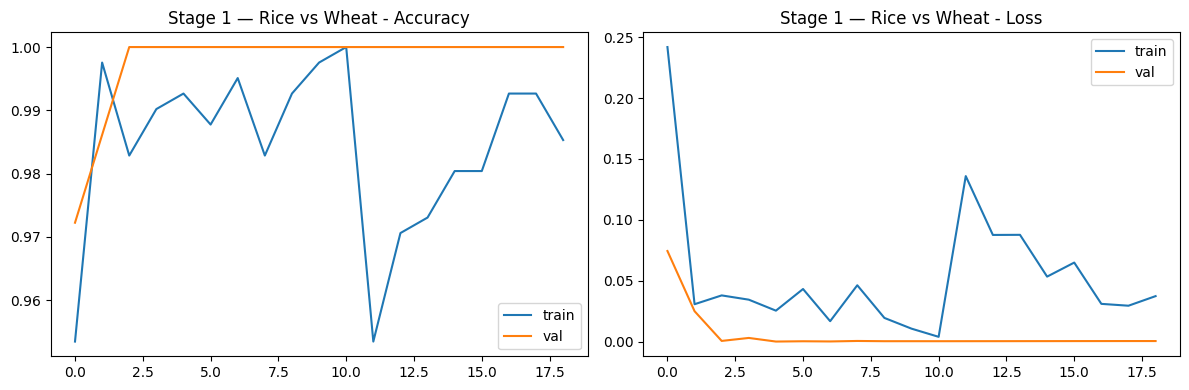

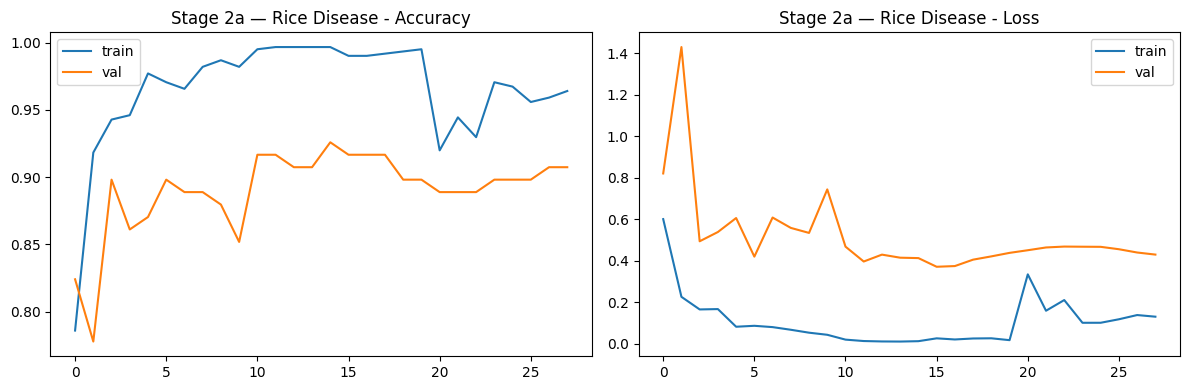

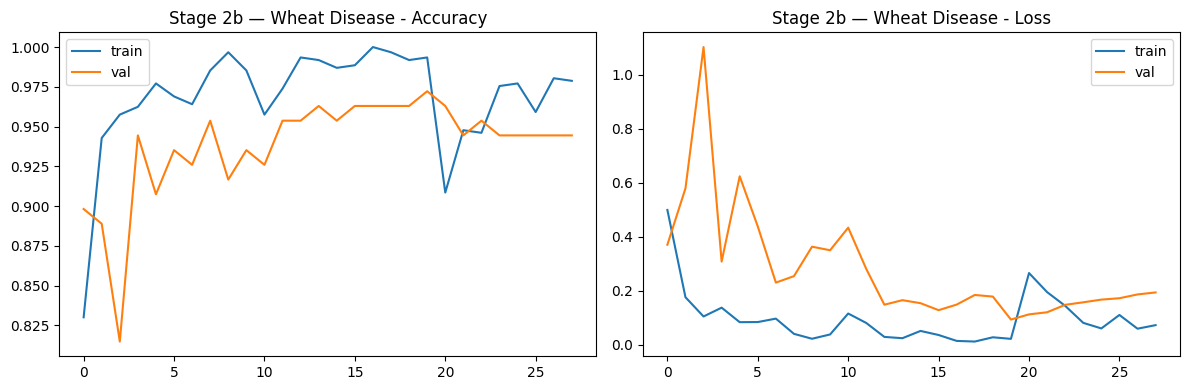

In [ ]:
# Cell 8: Plot training curves

import matplotlib.pyplot as plt

# Helper function
def plot_history(history, title):
    if history is None:
        print(f"{title}: history is None")
        return

    plt.figure(figsize=(12,4))

    # Accuracy plot
    plt.subplot(1,2,1)
    if 'accuracy' in history.history:
        plt.plot(history.history['accuracy'], label='train')
        plt.plot(history.history.get('val_accuracy', []), label='val')
        plt.title(f"{title} - Accuracy")
        plt.legend()
    else:
        print(f"{title}: No accuracy data found")

    # Loss plot
    plt.subplot(1,2,2)
    if 'loss' in history.history:
        plt.plot(history.history['loss'], label='train')
        plt.plot(history.history.get('val_loss', []), label='val')
        plt.title(f"{title} - Loss")
        plt.legend()
    else:
        print(f"{title}: No loss data found")

    plt.tight_layout()
    plt.show()


# ---- CALLS (your original lines) ----
plot_history(history_s1, "Stage 1 — Rice vs Wheat")
plot_history(history_rice, "Stage 2a — Rice Disease")
plot_history(history_wheat, "Stage 2b — Wheat Disease")

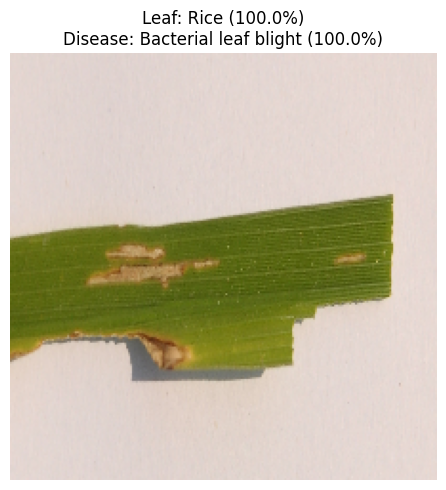

Leaf Type : Rice
Disease   : Bacterial leaf blight
Confidence: 100.00%


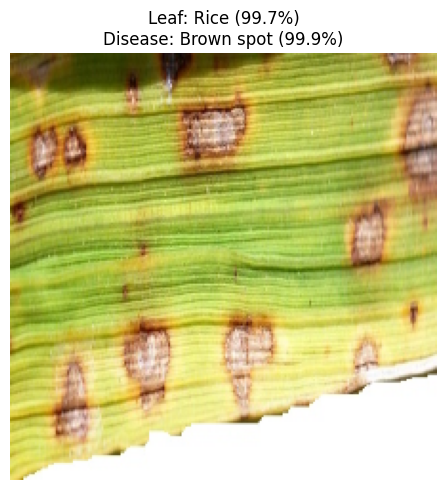

Leaf Type : Rice
Disease   : Brown spot
Confidence: 99.95%


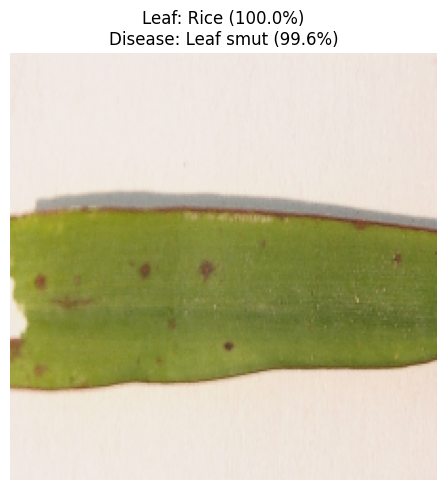

Leaf Type : Rice
Disease   : Leaf smut
Confidence: 99.62%


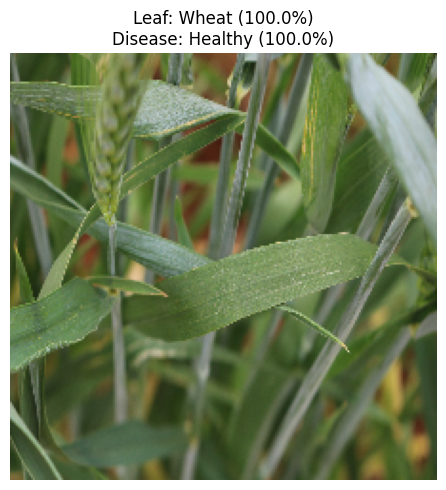

Leaf Type : Wheat
Disease   : Healthy
Confidence: 99.99%


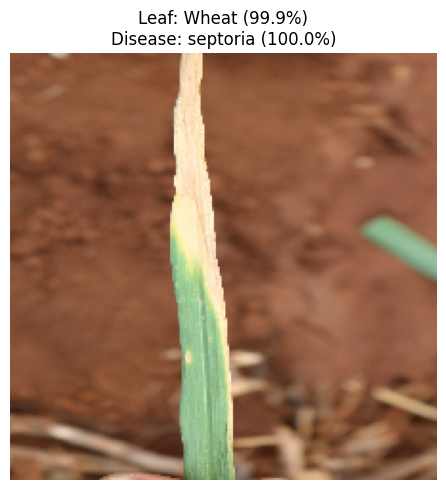

Leaf Type : Wheat
Disease   : septoria
Confidence: 99.96%


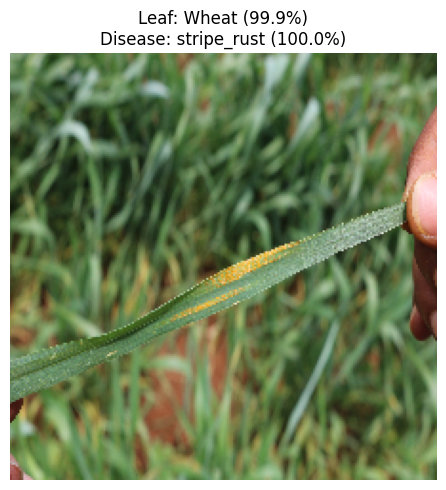

Leaf Type : Wheat
Disease   : stripe_rust
Confidence: 99.98%


In [ ]:
# Prediction

def predict_leaf(image_path):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print("image not found")
        return

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_input = np.expand_dims(img_resized.astype(np.float32) / 255.0, axis=0)

    # stage 1
    s1_prob = m_s1.predict(img_input, verbose=0)[0][0]
    if s1_prob > 0.5:
        leaf_type = "Wheat"
        leaf_conf = s1_prob
    else:
        leaf_type = "Rice"
        leaf_conf = 1.0 - s1_prob

    # stage 2
    if leaf_type == "Rice":
        probs = m_rice.predict(img_input, verbose=0)[0]
        classes = RICE_CLASSES
    else:
        probs = m_wheat.predict(img_input, verbose=0)[0]
        classes = WHEAT_CLASSES

    disease_idx = np.argmax(probs)
    disease_name = classes[disease_idx]
    disease_conf = probs[disease_idx]

    # show result
    plt.figure(figsize=(6,5))
    plt.imshow(img_resized)
    plt.axis('off')
    plt.title(f"Leaf: {leaf_type} ({leaf_conf*100:.1f}%)\nDisease: {disease_name} ({disease_conf*100:.1f}%)", fontsize=12)
    plt.tight_layout()
    plt.show()

    print("Leaf Type :", leaf_type)
    print("Disease   :", disease_name)
    print("Confidence:", f"{disease_conf*100:.2f}%")

# ── Run on your test images ──
test_images = [
    '/content/rice_leaf_diseases/Bacterial leaf blight/DSC_0366.jpg',
    '/content/rice_leaf_diseases/Brown spot/DSC_0105.jpg',
    '/content/rice_leaf_diseases/Leaf smut/DSC_0316.JPG',
    '/content/wheat_leaf/Healthy/loh(14).JPG',
    '/content/wheat_leaf/septoria/los(16).JPG',
    '/content/wheat_leaf/stripe_rust/lolr(106).JPG'
]

for path in test_images:
    predict_leaf(path)

In [ ]:
m_s1.save("plant_classifier.keras")
m_rice.save("rice_disease.keras")
m_wheat.save("wheat_disease.keras")

In [ ]:
from google.colab import files
files.download("plant_classifier.keras")
files.download("rice_disease.keras")
files.download("wheat_disease.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>